[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap02/cap02_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Da Captura ao Pixel - Amostragem, Quantização e Conectividade

Este capítulo aprofunda a compreensão da imagem digital, transitando da natureza física da captura para a sua representação matemática discreta. Investigamos como a luz se torna dado e como a organização espacial dos pixels define as relações de vizinhança e conectividade essenciais para algoritmos avançados de Visão Computacional.

## Objetivos

Ao final deste capítulo, você será capaz de:

- Explicar o modelo físico de formação da imagem baseado em iluminação e refletância.
- Diferenciar os mecanismos da visão humana e dos sensores digitais.
- Compreender os processos de **amostragem** (discretização do espaço) e **quantização** (discretização da intensidade).
- Descrever as relações topológicas entre pixels: vizinhança, adjacência, conectividade e distâncias.
- Realizar transformações geométricas básicas (translação, rotação, escala) preservando a qualidade.
- Visualizar na prática os efeitos da variação da resolução espacial e da profundidade de bits.

## O Olho e a Câmera - Elementos da Percepção Visual

A formação de uma imagem digital começa com a captura da luz refletida pelos objetos. Como ilustrado na @fig-02-olho, tanto o olho humano quanto as câmeras digitais seguem princípios ópticos semelhantes para focar a luz em uma superfície sensível, embora utilizem mecanismos biológicos e eletrônicos distintos para a transdução do sinal.

### Visão humana

O olho funciona como um sistema óptico complexo: a luz atravessa a córnea, o humor aquoso, a pupila (controlada pela íris) e o cristalino — que ajusta o foco dinamicamente — até atingir a retina. Na retina, encontram-se os fotorreceptores: os **cones** (≈6 milhões), concentrados na fóvea, são responsáveis pela visão de cores e detalhes, enquanto os **bastonetes** (≈120 milhões) garantem a visão em baixa luminosidade (visão escotópica), detectando apenas intensidades de cinza. O ponto cego é a região de onde parte o nervo óptico, carecendo de receptores.

### Sensores digitais

Nas câmeras, os sensores de imagem desempenham o papel da retina. Os dois tipos mais comuns são o **CCD** (*Charge-Coupled Device* - Dispositivo de Carga Acoplada) e o **CMOS** (*Complementary Metal-Oxide-Semiconductor* - Semicondutor de Óxido Metálico Complementar). O sensor é composto por uma matriz de fotossítios (pixels) que acumulam carga elétrica proporcional à luz incidente.

Para a reconstrução de cores, utiliza-se o **Filtro de Bayer**, uma matriz de filtros coloridos que permite que cada pixel capture apenas uma componente de cor: vermelho, verde ou azul (RGGB - *Red, Green, Green, Blue*). Posteriormente, um **ADC** (*Analog-to-Digital Converter* - Conversor Analógico-Digital) quantiza essa carga em valores numéricos, definidos por uma profundidade de bits (ex.: 8 bits, resultando em 256 níveis de intensidade).

> **Curiosidade:** Embora o olho humano tenha milhões de receptores, a resolução de alta definição é restrita à fóvea (visão central), equivalente a aproximadamente 120 × 120 pixels. A percepção de uma cena completa em alta resolução é fruto de um intenso pós-processamento realizado pelo cérebro.

::: {#fig-02-olho}

![](imagens/fig-02-olho.png){width=100% fig-align="center"}

Comparativo didático entre o sistema visual biológico e o eletrônico: no topo, a anatomia do olho humano destacando a retina e os fotorreceptores (cones e bastonetes); abaixo, a estrutura de uma câmera digital detalhando o sensor CMOS, a matriz de filtros de Bayer (RGGB) e o processo de quantização digital realizado pelo ADC.
:::


## Ilusões de Ótica: Os Desafios da Percepção Visual

Enquanto os sensores digitais capturam a intensidade da luz de forma linear e objetiva, o sistema visual humano interpreta a cena com base em contexto, experiências prévias e mecanismos biológicos de sobrevivência. As ilusões de ótica não são "erros" do olho, mas evidências do intenso **pós-processamento cerebral** realizado no córtex visual.

### Ambiguidade e Contexto

O cérebro busca constantemente dar sentido a padrões ambíguos. No exemplo do **Vaso de Rubin** (veja a @fig-02-ilusao), a percepção alterna entre a figura (vaso) e o fundo (dois rostos), demonstrando que não conseguimos processar ambas as interpretações simultaneamente. Já a ilusão do **[Elefante de Shepard](https://en.wikipedia.org/wiki/Shepard_elephant)** brinca com a nossa incapacidade de reconciliar linhas de contorno que sugerem volume em posições logicamente impossíveis.

### Brilho e Contraste Local

Muitas ilusões decorrem da **inibição lateral**, mecanismo pelo qual neurônios vizinhos na retina competem entre si para realçar bordas. Na **[Grade de Scintillating](https://en.wikipedia.org/wiki/Grid_illusion#/media/File:Grid_illusion.svg)**, pontos escuros "fantasmas" parecem surgir nas interseções brancas devido a esse processamento local de contraste.

A ilusão da **[Sombra no Tabuleiro de Adelson](https://en.wikipedia.org/wiki/Checker_shadow_illusion)** é talvez a mais impactante para a Visão Computacional: o quadrado "A" e o quadrado "B" possuem exatamente o mesmo valor de cinza no sensor (ou arquivo digital), mas o cérebro "corrige" o brilho de "B" por entender que ele está sob uma sombra projetada, percebendo-o como mais claro.

### Geometria e Perspectiva

A percepção de profundidade pode ser enganada por construções geométricas que desafiam a lógica tridimensional a partir de um ângulo de visão específico. A **[Escada de Schröder](https://www.youtube.com/watch?v=5DYeAkx2IBo)** utiliza a ambiguidade da perspectiva para criar um objeto que parece subir ou descer dependendo de como é observado, evidenciando como a nossa interpretação de "cima" e "baixo" depende do ponto de fuga.

::: {#fig-02-ilusao}

![](imagens/fig-02-ilusao.png){width=100% fig-align="center"}

Coletânea de desafios perceptivos: (topo esquerdo) Vaso de Rubin — ambiguidade figura-fundo; (topo central) Elefante de Shepard — incongruência geométrica; (topo direita) Sombra de Adelson — constância de brilho baseada no contexto; (inferior esquerdo) Grade de pontos — inibição lateral; (inferior direito) Escada de Schröder.
:::


## O Modelo Matemático da Formação da Imagem

Uma imagem pode ser modelada como o produto de duas funções:

$$
f(x,y) = i(x,y) \cdot r(x,y)
$$ {#eq-02-imagem}

onde:

- $i(x,y)$ é a **iluminação** incidente sobre a cena (energia luminosa por unidade de área). Depende da fonte de luz.
- $r(x,y)$ é a **refletância** do objeto (fração da luz refletida). Depende das propriedades do material e da superfície.

Na prática, as duas componentes variam em faixas distintas: $i(x,y)$ varia lentamente no espaço, enquanto $r(x,y)$ pode variar rapidamente (texturas, bordas). O processamento de imagens frequentemente tenta separar ou compensar essas componentes (ex.: correção de iluminação não uniforme).

## Digitalização: Amostragem e Quantização

Para transformar uma cena contínua em uma imagem digital, dois processos são necessários.

### Amostragem - Discretização do espaço

A amostragem consiste em medir o valor da função $f(x,y)$ em pontos igualmente espaçados, formando uma matriz de $M$ linhas (altura) e $N$ colunas (largura). Cada elemento dessa matriz é um **pixel**. A **resolução espacial** é dada por $M \times N$. Quanto maior a resolução, mais detalhes espaciais são preservados, mas maior também o custo computacional e de armazenamento.

### Quantização - Discretização da intensidade

A quantização associa a cada pixel um valor numérico discreto, geralmente representado por um inteiro de $b$ bits. A **profundidade de bits** define o número de níveis de intensidade: $2^b$. Imagens em tons de cinza costumam usar 8 bits (256 níveis). Imagens coloridas usam três canais de 8 bits (24 bits no total).


**Ilustração:** Se usarmos apenas 1 bit por pixel (preto e branco), perdemos todos os tons intermediários. Com 2 bits (4 níveis) já se percebe degradês grosseiros. Com 8 bits, o olho humano dificilmente percebe a discretização (visão contínua).

::: {.callout-warning}
### Erro de quantização {.unnumbered}
**Erro de quantização** é a diferença entre o valor analógico real e o valor discreto atribuído. Ele se manifesta como ruído de quantização, visível em regiões com gradiente suave quando se usa poucos bits (efeito de "posterização").
:::

### Laboratório prático: Efeitos da amostragem e quantização

Os experimentos a seguir mostram como a redução da resolução espacial (subamostragem) e da profundidade de bits degradam a qualidade visual. Use o código para explorar diferentes fatores e níveis de cinza.

In [1]:
#| quarto-raw: true

import os, importlib, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Baixar morph.py se necessário
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

print("✅ Ambiente pronto")

✅ Ambiente pronto


In [2]:
#| quarto-raw: true

# Carregar imagem de exemplo
base = "https://upload.wikimedia.org/wikipedia/commons"

arquivo = (
    "Area_de_Prote%C3%A7%C3%A3o_Ambiental_"
    "Quilombos_do_M%C3%A9dio_Ribeira_-_Thomas-"
    "Fuhrmann_%282023-_02%29_Malacoptila_striata.jpg"
)

url = f"{base}/c/c5/{arquivo}"

img_color = mm.read(url)
img_gray0 = mm.gray(img_color)
print(f"Imagem original: {img_color.shape}")
print(f"Tipo da imagem: {type(img_color)}")

Imagem original: (3067, 2047, 3)
Tipo da imagem: <class 'numpy.ndarray'>


O experimento apresentado na @fig-02-subamostragem ilustra o compromisso entre a **resolução espacial** e o **custo de armazenamento** em memória. O código utiliza a técnica de subamostragem por fatiamento (*slicing*) para reduzir a matriz original de pixels conforme um fator $f$, resultando em uma economia drástica de memória — por exemplo, um fator $f=8$ reduz o tamanho do dado em 64 vezes ($8^2$). Para fins de comparação visual, as imagens reduzidas são restauradas às dimensões originais ($512 \times 512$) através da interpolação por **vizinho mais próximo** (`nearest`). Este processo não recupera a informação perdida, mas torna evidente o efeito de **aliasing** e a estrutura de blocos (pixelização) gerada pela baixa densidade de dados da matriz amostrada.


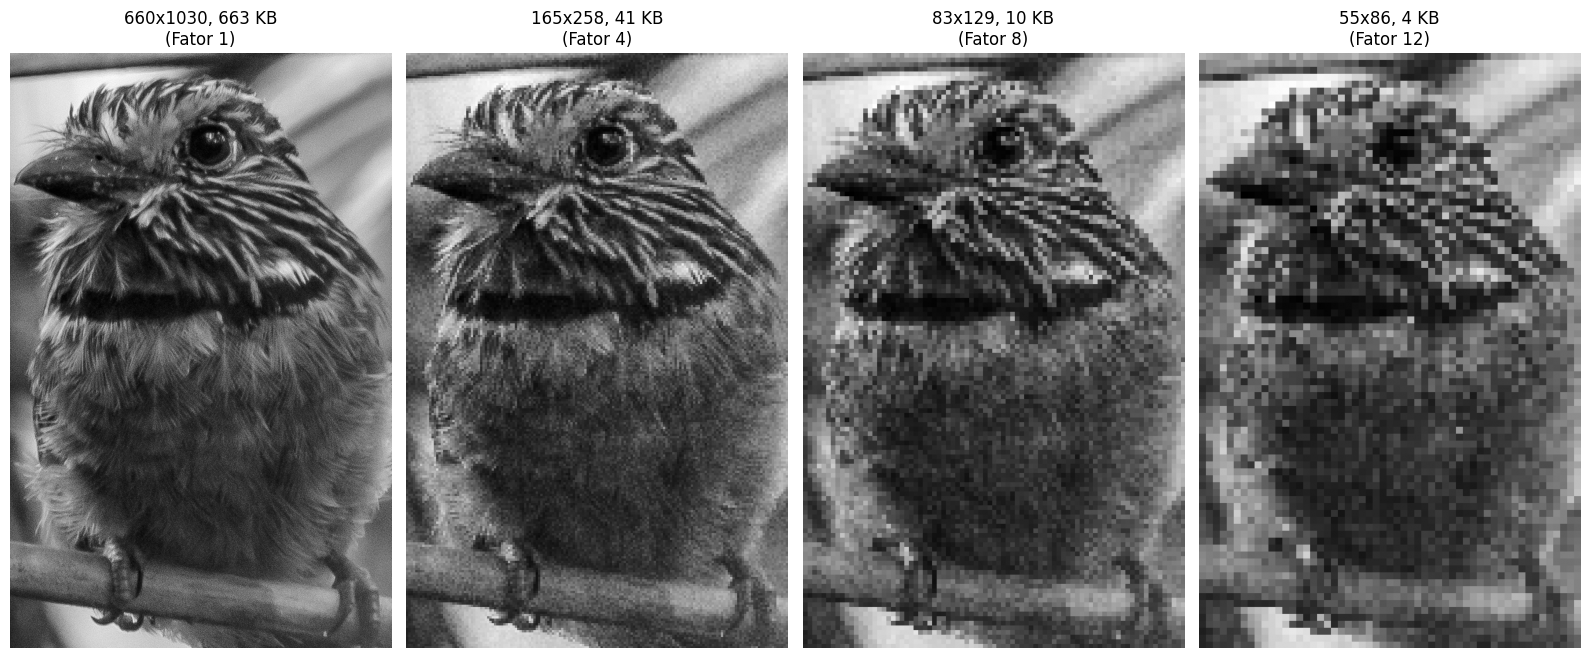

In [3]:
#| label: fig-02-subamostragem
#| fig-cap: "Efeito da subamostragem. Os títulos exibem as dimensões (W x H) e o tamanho da matriz em memória (KB)."
#| echo: true
#| output: true

def subsample_simple(image, f):
    # Subamostragem via fatiamento (slicing)
    reduced = image[::f, ::f]
    
    # Cálculo de memória em KB
    mem_kb = reduced.nbytes / 1024
    label = f"{reduced.shape[1]}x{reduced.shape[0]}, {int(mem_kb)} KB\n(Fator {f})"
    
    # Restaura o tamanho para visualização (H, W originais)
    res = mm.resize(reduced, (image.shape[1], image.shape[0]), method='nearest')
    return res, label

factors = [1, 4, 8, 12]
img_gray =img_gray0[820:1850, 890:1550] # Recorte para melhor visualização dos detalhes

# Gera os resultados e separa em listas para o mm.show
results = [subsample_simple(img_gray, f) for f in factors]
imgs_list = [r[0] for r in results]
titles_list = [r[1] for r in results]

mm.show(imgs_list, titles=titles_list, cols=4, figsize=(16, 12))

O experimento na @fig-02-quantizacao foca na **quantização de intensidade**, o processo de discretização da amplitude da função $f(x,y)$. Enquanto a subamostragem afeta a grade espacial, a redução da profundidade de bits limita a quantidade de tons de cinza disponíveis para representar o brilho.

Ao reduzir a profundidade de 8 bits (256 níveis) para valores menores, surge o efeito de **posterização**, onde os gradientes suaves de uma cena são substituídos por transições abruptas. No limite de 1 bit, a imagem torna-se estritamente binária, preservando apenas a silhueta e perdendo detalhes de textura e volume.


### Análise Técnica

* **Domínio vs. Codomínio**: Note que a resolução espacial (dimensões da matriz) permanece constante em 512x512; o que se altera é apenas o codomínio da função da imagem.
* **Constância de Memória**: Observe nos títulos que o tamanho em KB não diminui. Isso ocorre porque o NumPy armazena cada pixel quantizado em um contêiner de 8 bits (`uint8`), independentemente de o valor real ser apenas 0 ou 1.
* **Percepção**: A degradação visual torna-se crítica abaixo de 4 bits, onde o olho humano começa a perceber as "fronteiras" artificiais criadas pela falta de tons intermediários.

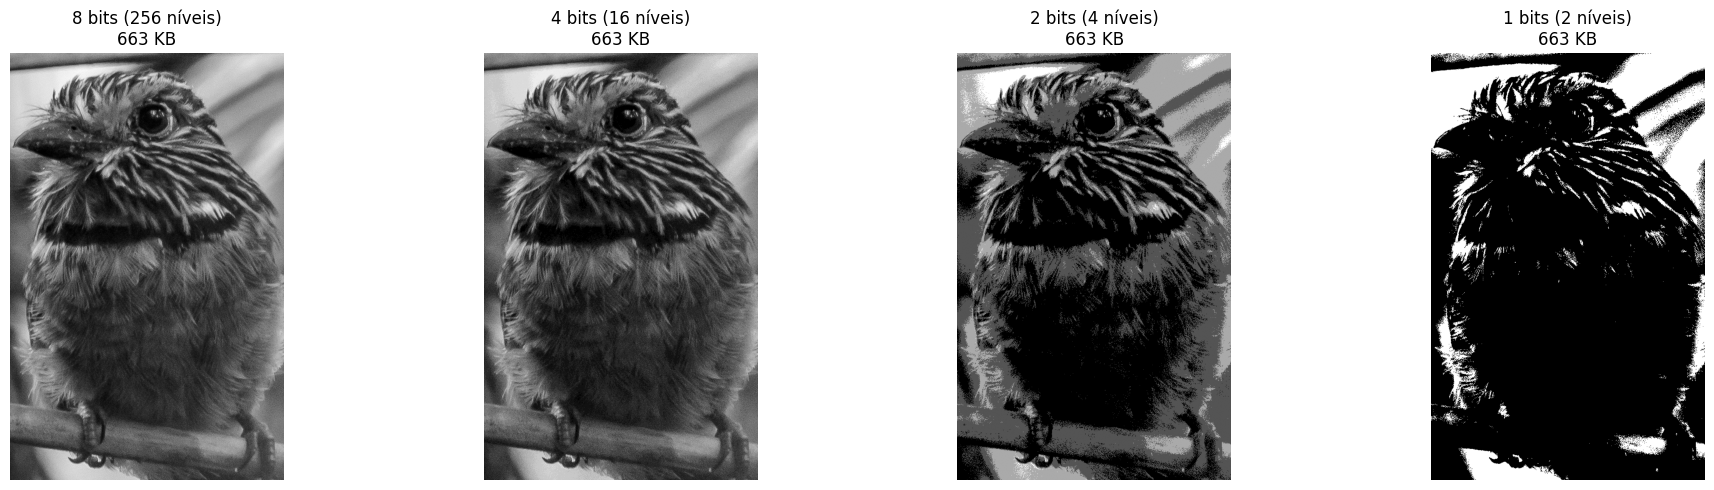

In [4]:
#| label: fig-02-quantizacao
#| fig-cap: "Efeito da redução da profundidade de bits. Os títulos exibem a quantidade de bits, níveis e o tamanho em memória (KB)."
#| echo: true
#| output: true

def quantize_simple(image, bits):
    """Reduz a profundidade de bits e calcula metadados de memória."""
    levels = 2 ** bits
    # Normalização e quantização uniforme
    quantized = (np.floor(image / 256 * levels) / levels * 255).astype(np.uint8)
    
    # Cálculo de memória em KB
    mem_kb = quantized.nbytes / 1024
    label = f"{bits} bits ({levels} níveis)\n{int(mem_kb)} KB"
    
    return quantized, label

# Lista de bits para teste (8 é o padrão, 1 é o binário)
bits_test = [8, 4, 2, 1]

# Gera os resultados e separa em listas para o mm.show
results_q = [quantize_simple(img_gray, b) for b in bits_test]
imgs_q = [r[0] for r in results_q]
titles_q = [r[1] for r in results_q]

mm.show(imgs_q, titles=titles_q, cols=4)

In [5]:
# Exemplo de compactação real para economia de memória
import numpy as np

# Imagem binária em uint8 (512x512)
img_uint8 = np.zeros((512, 512), dtype=np.uint8) 
print(f"Tamanho uint8: {img_uint8.nbytes / 1024} KB") # 256 KB

# Imagem compactada (Bit-packing)
img_packed = np.packbits(img_uint8)
print(f"Tamanho Compactado: {img_packed.nbytes / 1024} KB") # 32 KB

Tamanho uint8: 256.0 KB
Tamanho Compactado: 32.0 KB


A limitação de tipos de dados menores que um byte no ecossistema Python/NumPy deve-se à arquitetura de hardware, que endereça a memória em blocos de 8 bits (Bytes). Para que se mantenha a compatibilidade com o OpenCV e se garanta a eficiência, mapeiam-se até mesmo elementos binários para contêineres de 1 byte (`uint8` ou `bool8`).

Embora linguagens como ANSI C permitam a compactação de 8 pixels por byte (*bit-packing*), tal abordagem exige a descompactação constante para cálculos e impõe alta complexidade na manipulação de ponteiros. Conforme a @tbl-02-dados, privilegia-se o uso de `uint8` pela facilidade no acesso a vizinhos e pela versatilidade em transformações geométricas. Além disso, métodos nativos do NumPy e OpenCV executam o processamento internamente em baixo nível (C/C++), o que torna operações vetorizadas mais rápidas do que implementações manuais com laços aninhados em Python.

| Característica | Python (NumPy/OpenCV) | ANSI C (Bit-packing) |
| --- | --- | --- |
| **Menor Unidade** | 1 Byte (8 bits) | 1 Bit |
| **Memória (Binária)** | 256 KB (para 512x512) | 32 KB (para 512x512) |
| **Velocidade** | Alta (Vetorização em C) | Variável (Lenta se houver bit-shift) |
| **Complexidade** | Baixa: Métodos prontos | Alta: Ponteiros e Máscaras |

: Comparativo entre estratégias de compactação e eficiência de processamento. {#tbl-02-dados}

## Relações entre Pixels - Topologia da Imagem

Os pixels não são elementos isolados; suas posições relativas definem importantes conceitos para processamento.

### Vizinhança

Dado um pixel de coordenadas $(x,y)$, definem-se dois tipos principais de vizinhança (para imagens em $grid$ retangular):

- **Vizinhança-4** (von Neumann): inclui os pixels nas posições $(x-1,y)$, $(x+1,y)$, $(x,y-1)$, $(x,y+1)$.
- **Vizinhança-8** (Moore): inclui todos os oito pixels adjacentes (acrescenta os quatro diagonais).

A escolha da vizinhança influencia operações como detecção de bordas, cálculo de gradientes e conectividade.

In [13]:

import morph
importlib.reload(morph)
from morph import mm

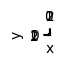

In [ ]:
#| label: fig-02-vizinhanca
#| fig-cap: "Ilustração de vizinhanças 4 em uma matriz 3x3. No centro (1,1), o pixel de interesse."
#| echo: true
#| output: true

# Criação de uma matriz 3x3 para exemplo topológico
viz = np.zeros((3, 3), dtype='uint8')

# Pixel central (p)
viz[1, 1] = 150 

# Definindo Vizinhança-4 (N4) com valor diferente para destaque
viz[0, 1] = viz[2, 1] = viz[1, 0] = viz[1, 2] = 255

# Exibição da matriz para análise de coordenadas
mm.drawImagePlt(viz, scale=40)

### Adjacência, conectividade e caminhos

Dois pixels são **adjacentes** se estão em contato segundo uma vizinhança definida **e** satisfazem um critério de valor (ex.: mesmo nível de intensidade). Uma **conectividade** define uma relação de equivalência entre pixels que formam uma região conexa. Um **caminho** é uma sequência de pixels adjacentes.

A conectividade-4 e conectividade-8 podem produzir resultados diferentes na segmentação e no cálculo de componentes conexas (etiquetagem). Por exemplo, um padrão de tabuleiro de xadrez pode ser completamente desconexo em 4-vizinhança, mas totalmente conexo em 8-vizinhança.

### Distâncias entre pixels

As métricas de distância são fundamentais para quantificar a proximidade física e a conectividade entre os elementos que compõem a grade digital. Conforme demonstrado na @tbl-02-distancias, a escolha da métrica define o custo de deslocamento entre pixels e altera o comportamento de algoritmos de segmentação e análise morfológica.

Para medir a distância entre dois pixels $p(x_1, y_1)$ e $q(x_2, y_2)$, utilizam-se diferentes funções métricas que impõem restrições de movimento distintas sobre o *grid*:

| Métrica | Definição | Interpretação |
|:--------|:----------|:--------------|
| **Euclidiana** | $\sqrt{(x_1-x_2)^2 + (y_1-y_2)^2}$ | Distância em linha reta (contínua) |
| ***Manhattan* (*City block*)** | $|x_1-x_2| + |y_1-y_2|$ | Movimentos horizontais + verticais |
| ***Chebyshev* (Tabuleiro)** | $\max(|x_1-x_2|, |y_1-y_2|)$ | Movimentos incluindo diagonais |

: Comparativo de métricas de distância aplicadas à malha de pixels. {#tbl-02-distancias}

Essas distâncias são aplicadas em diversos contextos de PDI, incluindo algoritmos de interpolação geométrica, transformadas de distância, crescimento de regiões e análise de formas.

::: {.callout-note}

### Exemplo prático

Considerando dois pixels com deslocamentos relativos $\Delta x = 3$ e $\Delta y = 4$:

* **Euclidiana**: $\sqrt{3^2 + 4^2} = 5$ (hipotenusa do triângulo retângulo).
* ***Manhattan***: $3 + 4 = 7$ (soma dos catetos).
* ***Chebyshev***: $\max(3, 4) = 4$ (predomínio do maior deslocamento).
:::

## Armazenamento de Imagens

A escolha do formato de arquivo é um passo decisivo no fluxo de processamento, pois determina como os dados de amostragem e quantização serão preservados ou descartados. Conforme se apresenta na @tbl-02-formatos, cada extensão equilibra de forma distinta a fidelidade dos dados e a eficiência de armazenamento.

As imagens digitais podem ser armazenadas em diversos formatos, cada um com características que impactam o processamento posterior:

| Formato | Características | Uso típico |
| --- | --- | --- |
| **PGM** | Formato simples de mapa de cinzas (texto ou binário). | Pesquisa acadêmica e ferramentas Unix. |
| **BMP** | Não comprimido (ou compressão simples). | Windows, aplicações legado. |
| **PNG** | Compressão sem perdas (*lossless*). | Web, imagens com transparência. |
| **JPEG** | Compressão com perdas (*lossy*), ideal para fotografias. | Fotos, imagens médicas (uso moderado). |
| **TIFF** | Suporta múltiplas camadas e compressão variada. | Editoração, arquivamento. |
| **RAW** | Dados brutos (sensor ou matriz sem cabeçalho). | Fotografia profissional e exames médicos. |

: Principais formatos de armazenamento e suas aplicações em PDI. {#tbl-02-formatos}

Os metadados de uma imagem incluem parâmetros como largura, altura, profundidade de bits e codificação de cor. Em formatos científicos, preservam-se também informações de calibração e detalhes da captura. Ao utilizar-se a função `mm.read()`, a biblioteca `morph` preserva automaticamente esses dados para que se respeitem as propriedades originais da imagem.

Em contextos científicos e hospitalares, privilegia-se o padrão **DICOM** para garantir que não haja perda de precisão diagnóstica. Repositórios públicos como o **[The Cancer Imaging Archive (TCIA)](https://www.cancerimagingarchive.net/)**, o **[Alzheimer’s Disease Neuroimaging Initiative (ADNI)](https://adni.loni.usc.edu/)** e o **[PhysioNet](https://physionet.org/)** disponibilizam vastos conjuntos de dados neste formato, incluindo metadados clínicos anonimizados que são essenciais para a investigação científica.


### Exemplo: Extração de Metadados e Localização GPS

Diferente da matriz de pixels pura obtida pela leitura convencional — como na imagem do pássaro apresentada no início deste capítulo —, o uso do argumento `info=True` no método `mm.read()` altera a natureza do objeto retornado (ver @fig-01-natureza). Enquanto o `imread` do OpenCV retorna um `numpy.ndarray` (padrão utilizado quando `info=False`), a leitura com informações preservadas retorna um objeto especializado da biblioteca Pillow, capaz de interpretar o cabeçalho **EXIF**.

O cabeçalho **EXIF** (*Exchangeable Image File Format*) funciona como um repositório técnico da captura, permitindo que o objeto Pillow interprete uma vasta gama de informações que vão muito além das coordenadas de GPS. Ao utilizar `info=True`, o sistema ganha acesso ao "DNA" da imagem, incluindo metadados de hardware (marca e modelo da câmera), configurações ópticas (abertura, distância focal e tempo de exposição) e parâmetros de iluminação (uso de flash e balanço de branco).

Essa distinção é importante no PDI, pois transforma a matriz de amostragem em um conjunto de dados contextualizado, onde as características físicas do sensor e da lente podem ser utilizadas para normalizar brilhos ou corrigir distorções geométricas.

GPS Decimal: -24.587955, -48.629758
Maps: https://www.google.com/maps/search/?api=1&query=-24.587955,-48.629758333333335

Tipo PIL: <class 'PIL.JpegImagePlugin.JpegImageFile'> | Dimensões (x,y): (2047, 3067)
Pillow (0,0) (x,y): (58, 95, 2)
Tipo NumPy: <class 'numpy.ndarray'> | Dimensões [y,x,c]: (3067, 2047, 3)
NumPy [0,0] [y,x]: [58 95  2]


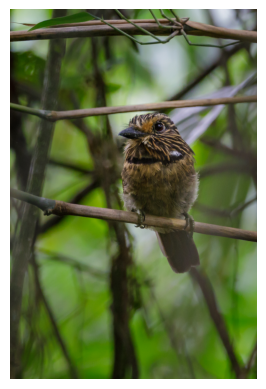

In [7]:
#| label: fig-01-natureza
#| fig-cap: "APA Quilombos do Médio Ribeira - Barbudo-rajado (Malacoptila striata). Crédito: Thomas Fuhrmann (CC BY-SA 4.0)."
#| echo: true

from PIL.ExifTags import TAGS
import numpy as np

base = "https://upload.wikimedia.org/wikipedia/commons"

arquivo = (
    "Area_de_Prote%C3%A7%C3%A3o_Ambiental_"
    "Quilombos_do_M%C3%A9dio_Ribeira_-_Thomas-"
    "Fuhrmann_%282023-_02%29_Malacoptila_striata.jpg"
)

url = f"{base}/c/c5/{arquivo}"

# 1. Leitura com metadados (PIL) e conversão para matriz (NumPy)
img_obj = mm.read(url, info=True)
img_numpy = np.array(img_obj)

# 2. Extração e conversão de GPS (Tag 34853)
exif = img_obj._getexif()
if exif and (gps := exif.get(34853)):
    to_dec = lambda dms, ref: float(-(dms[0]+dms[1]/60+dms[2]/3600) if ref in 'SW' 
                                    else (dms[0]+dms[1]/60+dms[2]/3600))
    lat, lon = to_dec(gps[2], gps[1]), to_dec(gps[4], gps[3])
    print(f"GPS Decimal: {lat:.6f}, {lon:.6f}")
    maps_url = f"https://www.google.com/maps/search/?api=1&query={lat},{lon}"
    # Formato correto para Google Maps Search API
    print(f"Maps: {maps_url}")

# 3. Diagnóstico de tipos, dimensões e acesso a pixels
# No Pillow (Coordenadas): (x, y) -> Ordem RGB
print(f"\nTipo PIL: {type(img_obj)} | Dimensões (x,y): {img_obj.size}")
print(f"Pillow (0,0) (x,y): {img_obj.getpixel((0, 0))}")

# No NumPy (Matriz): [linha, coluna] -> Ordem RGB
print(f"Tipo NumPy: {type(img_numpy)} | Dimensões [y,x,c]: {img_numpy.shape}")
print(f"NumPy [0,0] [y,x]: {img_numpy[0, 0]}")

# 4. Exibição
mm.show(img_obj)



::: {.callout-note}

### Nota Pedagógica: A sutil diferença das dimensões

Repare que a representação das dimensões muda conforme a estrutura de dados utilizada:

* **No Pillow (`.size`):** Retorna `(Largura, Altura)`. É uma visão orientada ao arquivo de imagem.
* **No NumPy (`.shape`):** Segue a convenção matemática de matrizes: `(Linhas/Altura, Colunas/Largura, Canais)`.

Esta distinção é fundamental para evitar erros de indexação ao implementar filtros manuais. Enquanto o objeto Pillow carrega o **"onde"** e o **"quando"** (contexto), o array NumPy carrega o **"quanto"** de luz (intensidade) existe em cada ponto da imagem.
:::

### Por que esta separação é importante?

Ao carregar uma imagem via `cv2.imread()`, o resultado é um `<class 'numpy.ndarray'>`, que contém estritamente os valores numéricos resultantes da **quantização** e **amostragem**. No entanto, ao utilizar `info=True`, o `mm.read()` retorna um objeto da classe `PIL.JpegImagePlugin.JpegImageFile`.

Esta classe mantém o arquivo "aberto" para permitir o acesso ao contexto da captura antes que os dados sejam convertidos em uma matriz bruta. Essa separação é vital: pixels servem para algoritmos; metadados servem para georreferenciamento, catalogação científica e correções baseadas no hardware de aquisição.

## Transformações Geométricas Básicas

As transformações geométricas alteram a posição dos pixels, mantendo os valores de intensidade. São fundamentais para alinhamento, correção de distorções e aumento de dados (*data augmentation*) em aprendizado de máquina.

Uma **transformação afim** é qualquer mapeamento que preserve colinearidade (pontos sobre uma reta permanecem sobre uma reta) e razões de distâncias entre pontos colineares. Em 2D, toda transformação afim pode ser expressa em **coordenadas homogêneas** por uma matriz $3 \times 3$:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}
=
\underbrace{\begin{bmatrix} a_{11} & a_{12} & t_x \\ a_{21} & a_{22} & t_y \\ 0 & 0 & 1 \end{bmatrix}}_{\mathbf{T}}
\begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
$$ {#eq-02-afim}

A sub-matriz $2 \times 2$ superior esquerda $\mathbf{A} = \begin{bmatrix} a_{11} & a_{12} \\ a_{21} & a_{22} \end{bmatrix}$ controla rotação, escala e cisalhamento; o vetor $(t_x, t_y)^\top$ controla a translação. As transformações geométricas mais usadas em PDI — translação, rotação e escala — são casos particulares de $\mathbf{T}$, e podem ser **compostas** por multiplicação de matrizes, na ordem $\mathbf{T} = \mathbf{T}_n \cdots \mathbf{T}_2 \mathbf{T}_1$.

::: {.callout-note}
### Transformação inversa e interpolação {.unnumbered}

Na implementação prática (`cv2.warpAffine`), aplica-se a **transformação inversa**: para cada pixel $(x', y')$ da imagem destino, calcula-se a posição de origem $(x, y) = \mathbf{T}^{-1}(x', y')$ e interpola-se o valor. Isso evita buracos na imagem resultante causados pelo mapeamento direto de pixels inteiros para posições não inteiras.
:::

### Translação

A translação é a transformação afim mais simples: desloca todos os pixels por um vetor $(t_x, t_y)$. Em coordenadas homogêneas, é expressa pela matriz:

$$
\begin{bmatrix} x' \\ y' \\ 1 \end{bmatrix}
=
\begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \\ 0 & 0 & 1 \end{bmatrix}
\begin{bmatrix} x \\ y \\ 1 \end{bmatrix}
\quad \Rightarrow \quad
\begin{cases} x' = x + t_x \\ y' = y + t_y \end{cases}
$$ {#eq-02-translacao}

A terceira linha da matriz garante que a operação permaneça no espaço afim, permitindo que translação, rotação e escala sejam combinadas por simples multiplicação de matrizes. Na prática, `cv2.warpAffine` usa apenas as duas primeiras linhas (matriz $2 \times 3$), pois a terceira é sempre $[0, 0, 1]$.

Pixels deslocados para além da área original são descartados; áreas descobertas são preenchidas com 0 (preto). Ver um exemplo na @fig-02-translacao.

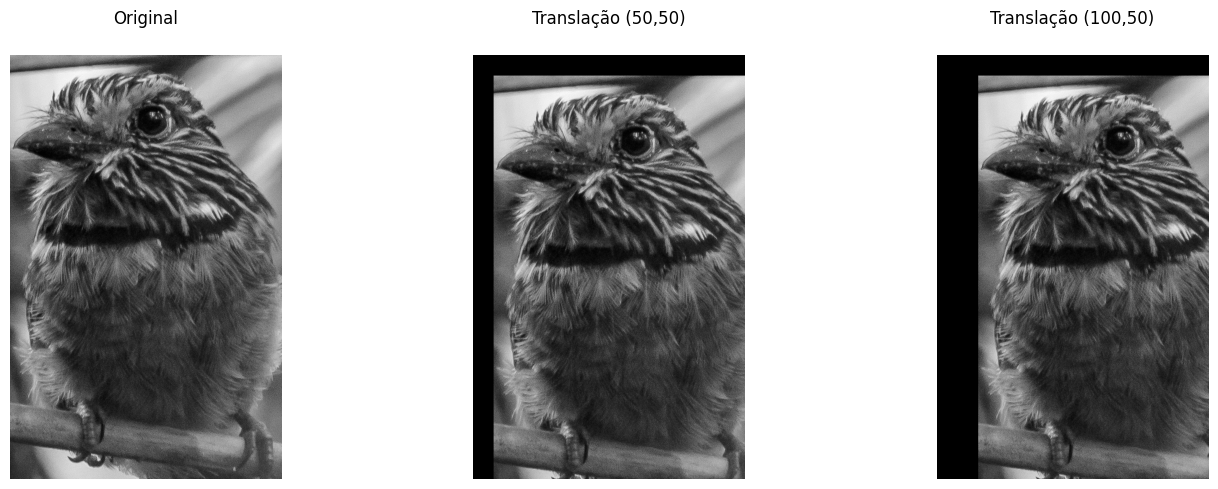

In [8]:
#| label: fig-02-translacao
#| fig-cap: "Exemplo de translação da imagem do pássaro com deslocamentos (50,50) e (100,50)."
#| echo: true
#| output: true
img_tx1 = mm.translate(img_gray, 50, 50)
img_tx2 = mm.translate(img_gray, 100, 50)
mm.show([img_gray, img_tx1, img_tx2],
        titles=["Original", "Translação (50,50)", "Translação (100,50)"],
        cols=3)

### Rotação

A rotação por ângulo $\theta$ em torno de um ponto central $(c_x, c_y)$ é composta por três transformações afins: translação para a origem, rotação pura e translação de volta. A matriz resultante é:

$$
\mathbf{T}_{\text{rot}} =
\begin{bmatrix}
\cos\theta & -\sin\theta & c_x(1-\cos\theta) + c_y\sin\theta \\
\sin\theta &  \cos\theta & c_y(1-\cos\theta) - c_x\sin\theta \\
0 & 0 & 1
\end{bmatrix}
$$ {#eq-02-rotacao}

Na implementação, `cv2.getRotationMatrix2D` gera diretamente as duas primeiras linhas de $\mathbf{T}_{\text{rot}}$ (matriz $2 \times 3$ para `warpAffine`), aceitando também um fator de escala $s$ que multiplica $\cos\theta$ e $\sin\theta$. Ver exemplo na @fig-02-rotacao.

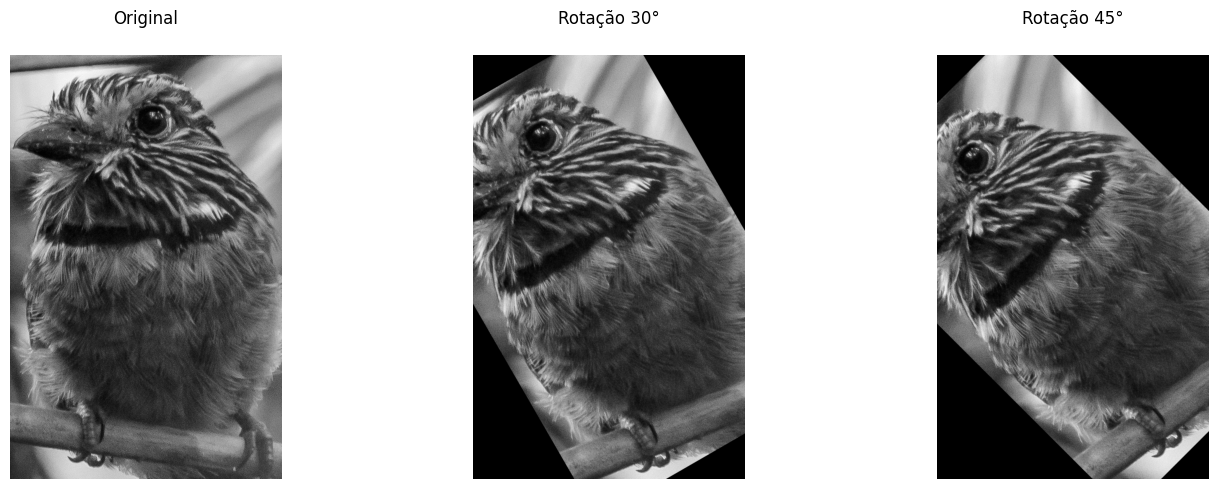

In [9]:
#| label: fig-02-rotacao
#| fig-cap: "Exemplo de rotação da imagem do pássaro em 30° e 45° usando interpolação bilinear."
#| echo: true
#| output: true

img_rot30 = mm.rotate(img_gray, 30, interp='bilinear')
img_rot45 = mm.rotate(img_gray, 45, interp='bilinear')

mm.show([img_gray, img_rot30, img_rot45],
        titles=["Original", "Rotação 30°", "Rotação 45°"],
        cols=3)

### Escala (Redimensionamento)

O redimensionamento por fatores $(s_x, s_y)$ é uma transformação afim com matriz:

$$
\mathbf{T}_{\text{escala}} =
\begin{bmatrix}
s_x & 0   & 0 \\
0   & s_y & 0 \\
0   & 0   & 1
\end{bmatrix}
$$ {#eq-02-escala}

Quando $s > 1$ (ampliação), pixels da imagem destino mapeiam para posições não inteiras na origem — exigindo **interpolação** para estimar o valor. Quando $s < 1$ (redução), múltiplos pixels de origem contribuem para um único pixel destino — exigindo **decimação**. Os três métodos disponíveis em `mm.resize` diferem na qualidade e no custo computacional, conforme a @tbl-02-interp:

| Método | Vizinhos usados | Característica |
|:-------|:---:|:---------------|
| `'nearest'`  | 1  | Rápido; produz efeito de blocos (*pixelation*) |
| `'bilinear'` | 4  | Bom compromisso qualidade/custo; bordas suaves |
| `'bicubic'`  | 16 | Maior nitidez; preferido em softwares profissionais |

: Métodos de interpolação disponíveis em `mm.resize` e seus respectivos números de vizinhos utilizados no cálculo. {#tbl-02-interp}

Imagem: (1030, 660) | Crop: (80, 80)


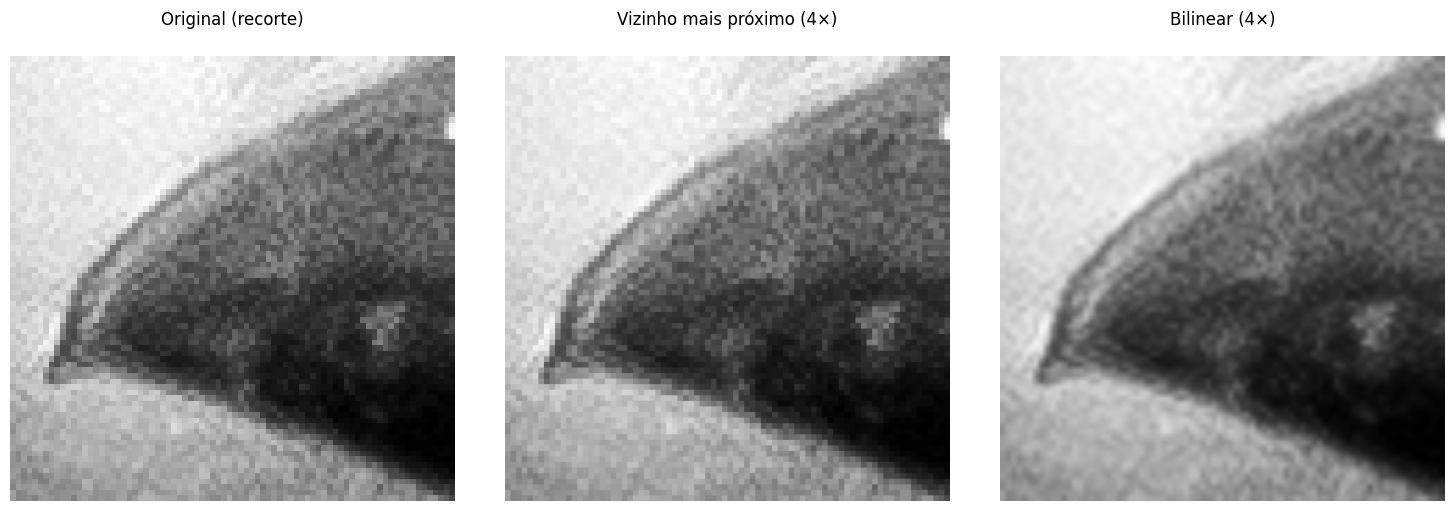

In [10]:
#| label: fig-02-escala-detalhe
#| fig-cap: "Comparação de interpolação com zoom no detalhe do olho (recorte 60×60, ampliado 4×). Note o efeito de blocos no vizinho mais próximo vs. a suavização na bilinear."
#| echo: true
#| output: true

# 1. Recorte da região do bico
y, x, offset = 210, 40, 40
crop = img_gray[y-offset:y+offset, x-offset:x+offset]
print(f"Imagem: {img_gray.shape} | Crop: {crop.shape}")

# 2. Ampliar 4× com mm.resize
crop_nearest  = mm.resize(crop, 4, method='nearest')
crop_bilinear = mm.resize(crop, 4, method='bilinear')

# 3. Exibição comparativa
mm.show(
    [crop, crop_nearest, crop_bilinear],
    titles=["Original (recorte)", "Vizinho mais próximo (4×)", "Bilinear (4×)"],
    cols=3
)

### Cisalhamento (*Shear*)

O cisalhamento é uma transformação afim que distorce a imagem ao deslocar cada pixel proporcionalmente à sua posição em um eixo. A matriz geral combina cisalhamento horizontal ($sh_x$) e vertical ($sh_y$):

$$
\mathbf{T}_{\text{cisalh}} =
\begin{bmatrix}
1    & sh_x & 0 \\
sh_y & 1    & 0 \\
0    & 0    & 1
\end{bmatrix}
$$ {#eq-02-cisalhamento}

Para $sh_x \neq 0$ e $sh_y = 0$, cada linha é deslocada horizontalmente proporcionalmente à sua posição vertical — produzindo o efeito de "inclinação" característico. Ver exemplo na @fig-02-cisalhamento.

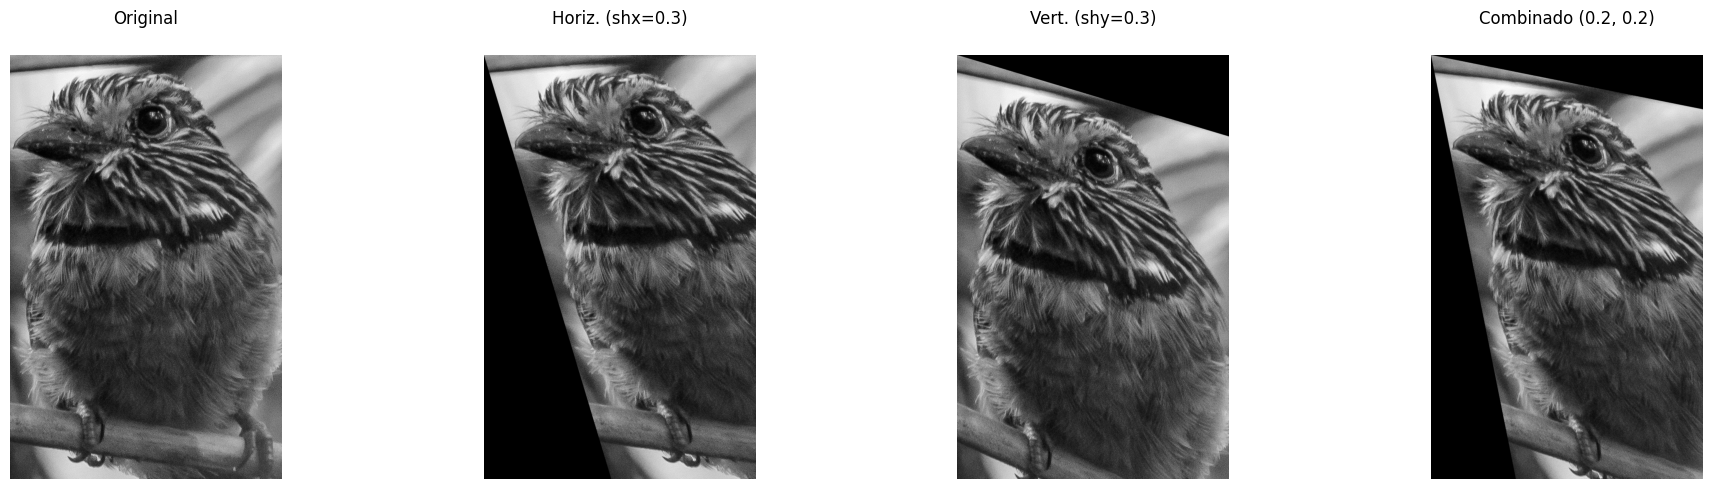

In [11]:
#| label: fig-02-cisalhamento
#| fig-cap: "Exemplo de cisalhamento da imagem do pássaro: horizontal (shx=0.3), vertical (shy=0.3) e combinado (shx=0.2, shy=0.2)."
#| echo: true
#| output: true

img_shx = mm.shear(img_gray, shx=0.3)
img_shy = mm.shear(img_gray, shy=0.3)
img_shc = mm.shear(img_gray, shx=0.2, shy=0.2)

mm.show(
    [img_gray, img_shx, img_shy, img_shc],
    titles=["Original", "Horiz. (shx=0.3)", "Vert. (shy=0.3)", "Combinado (0.2, 0.2)"],
    cols=4
)

## Resumo

Neste capítulo foram apresentados os fundamentos de digitalização e topologia de imagens:

- **Formação da imagem:** $f(x,y) = i(x,y) \cdot r(x,y)$.
- **Amostragem:** discretização do espaço → resolução espacial $M \times N$.
- **Quantização:** discretização da intensidade → profundidade de bits $b$.
- **Relações topológicas:** vizinhança-4, vizinhança-8, conectividade, distâncias (Euclidiana, Manhattan, Chebyshev).
- **Transformações geométricas:** translação, rotação, escala (com interpolação bilinear ou vizinho mais próximo).
- **Formatos de arquivo:** BMP, PNG, JPEG, TIFF, RAW; cada um com diferentes compromissos entre qualidade e tamanho.

O Capítulo 3 abordará **operações espaciais** como convolução, filtragem e morfologia matemática (erosão, dilatação).

## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelo autor como base de conhecimento, garantindo respostas coerentes com o conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

::: {.callout-important appearance="default" icon=false}
### 🎓 Estude com o Tutor Inteligente {.unnumbered}

Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 02](https://notebooklm.google.com/notebook/de34f858-ac9d-4b90-a80d-466b701efe31)
:::

## Lista de Exercícios

1. **(15%)** Explique, com suas próprias palavras, a diferença entre **amostragem** e **quantização**. Dê um exemplo concreto de cada uma no contexto de uma imagem digital.

2. **(15%)** Considere uma imagem com resolução espacial de 1024 × 768 pixels e profundidade de 24 bits (8 bits por canal RGB). Calcule o tamanho total não comprimido da imagem em bytes e em megabytes.

3. **(20%)** Utilizando o código do laboratório, modifique o fator de subamostragem para 3 e para 6. Descreva visualmente o que ocorre com as bordas dos objetos. O que é o efeito de *aliasing*?

4. **(20%)** Para a imagem em tons de cinza, aplique quantização com 3 bits (8 níveis) e 5 bits (32 níveis). Compare os resultados e explique por que 5 bits já pode ser considerado suficiente para muitas aplicações.

5. **(15%)** Dados dois pixels $A=(10,20)$ e $B=(15,25)$, calcule as distâncias Euclidiana, Manhattan e Chebyshev entre eles.

6. **(15%)** Usando a função `mm.rotate`, gire a imagem do pássaro em ângulos de 90°, 180° e 270° com interpolação bilinear. Compare com a rotação usando `method='nearest'`. Em quais situações a interpolação vizinho mais próximo ainda é útil?

## Referências do Capítulo {.unnumbered}

A fundamentação teórica deste capítulo baseia-se nas seguintes obras:

* @gonzalez2018digital para os conceitos de amostragem, quantização e relações entre pixels.
* @szeliski2022 para transformações geométricas e conectividade.
* @bradski2008learning para a implementação prática com OpenCV e `morph.py`.